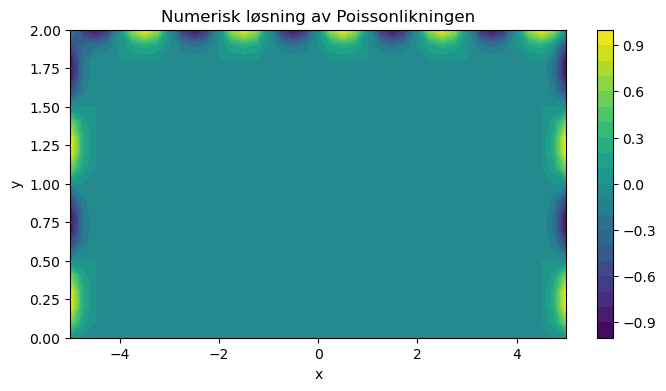

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Oppgave 5: Poissonlikning
# u_xx + u_yy = 0
# -5 < x < 5 , 0 < y < 2

# Antall gridpunkter
Nx = 41
Ny = 21

# Domene
x = np.linspace(-5,5,Nx)
y = np.linspace(0,2,Ny)

dx = x[1]-x[0]
dy = y[1]-y[0]

# Løsningsmatrise
u = np.zeros((Ny,Nx))


# venstre og høyre kant
for j in range(Ny):
    u[j,0]  = np.sin(2*np.pi*y[j])
    u[j,-1] = np.sin(2*np.pi*y[j])

# bunn
for i in range(Nx):
    u[0,i] = 0

# topp
for i in range(Nx):
    u[-1,i] = np.sin(np.pi*x[i])


# Numerisk løsning (Jacobi-metoden)

u_ny = u.copy()

iterations = 5000

for k in range(iterations):
    
    for j in range(1,Ny-1):
        for i in range(1,Nx-1):
            
            u_ny[j,i] = 0.25*(
                u[j,i+1] +
                u[j,i-1] +
                u[j+1,i] +
                u[j-1,i]
            )
    
u = u_ny.copy()



X,Y = np.meshgrid(x,y)

plt.figure(figsize=(8,4))
plt.contourf(X,Y,u,20)
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Numerisk løsning av Poissonlikningen")
plt.show()

Oppgave 6a steking av biff
Gjenstand: en rektangulær biff
Termisk diffusivitet α: 1.3e-07
Tvverrsnitt Dimensjoner: brede_x= 0.2 cm tykkelse_y= 0.05 cm


numerisk løsning...


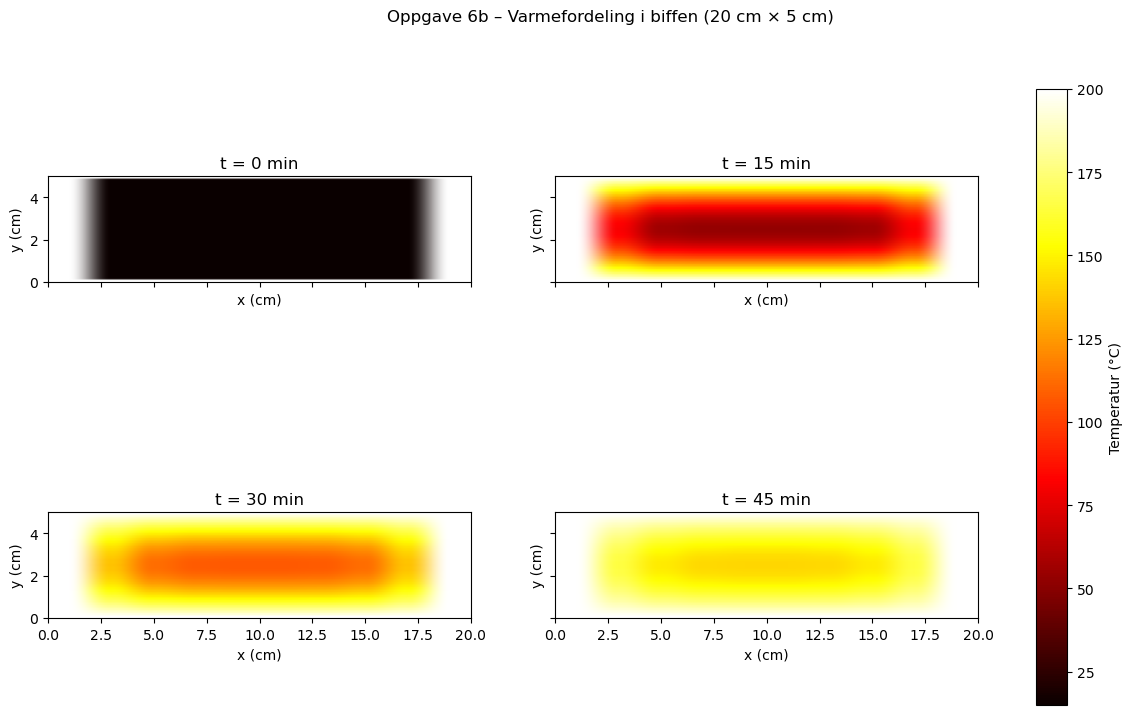

Oppgave 6c – Temperatur i midten av biffen:
  t =   0 min → midten =  15.0 °C
  t =  15 min → midten =  53.2 °C
  t =  30 min → midten = 106.9 °C

Midten når ca. 60 °C etter ca. 30 minutter

Oppgave 6d – Animasjon


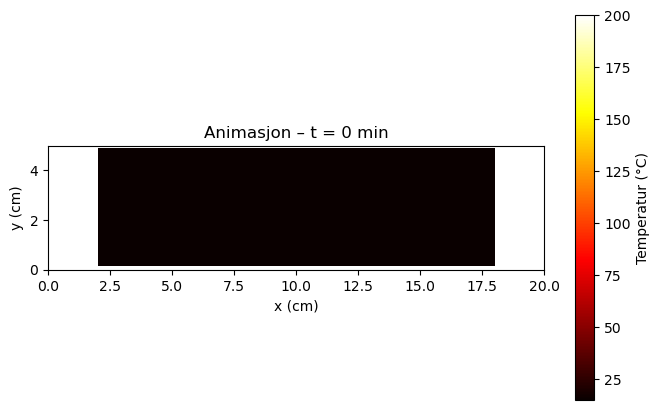

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
plt.close("all")

alpha = 1.3e-7              
bredde_x = 0.2             
tykkelse_y = 0.05

print("Oppgave 6a steking av biff")
print("Gjenstand: en rektangulær biff")
print("Termisk diffusivitet α:", alpha)
print("Tvverrsnitt Dimensjoner: brede_x=", bredde_x, "cm", "tykkelse_y=", tykkelse_y, "cm")
print()
print()


# Oppgave 6b partielle differensiallikningen, rand- og initialbetingelser. Løs deretter likningen numerisk.

antall_x = 10              
antall_y = 41

x = np.linspace(0, bredde_x, antall_x)
y = np.linspace(0, tykkelse_y, antall_y)
dx = x[1] - x[0]
dy = y[1] - y[0]

# Tidssteg 
tidssteg = 0.4 * min(dx**2, dy**2) / alpha
total_tid = 9000            
antall_tid = int(total_tid / tidssteg) + 1


# start temperatur = 15 °C
temperatur = np.full((antall_y, antall_x), 15.0)

# Randbetingelse: 200 °C på alle kanter
temperatur[:, 0]   = 200
temperatur[:, -1]  = 200
temperatur[0, :]   = 200
temperatur[-1, :]  = 200

# Tidspunkter vi vil lagre
lagre_tider = [0, 900, 1800, 2700,]  
lagrede = {0: temperatur.copy()}
aktuell_tid = 0.0


# eksplisitt Euler

print("numerisk løsning...")

for steg in range(antall_tid):
    temp_ny = temperatur.copy()
    temp_ny[1:-1, 1:-1] = temperatur[1:-1, 1:-1] + alpha * tidssteg * (
        (temperatur[1:-1, 2:]   - 2*temperatur[1:-1, 1:-1] + temperatur[1:-1, :-2])   / dx**2 +
        (temperatur[2:,   1:-1] - 2*temperatur[1:-1, 1:-1] + temperatur[:-2,  1:-1]) / dy**2
    )
    
# rand = 200 °C
    temp_ny[:, 0]   = 200
    temp_ny[:, -1]  = 200
    temp_ny[0, :]   = 200
    temp_ny[-1, :]  = 200
    
    temperatur = temp_ny
    aktuell_tid += tidssteg
    
# valgte tidspunkter
    for ts in lagre_tider[1:]:
        if ts not in lagrede and aktuell_tid >= ts:
            lagrede[ts] = temperatur.copy()

#varmebilder

X, Y = np.meshgrid(x * 100, y * 100)  # i cm

fig, akser = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)
akser = akser.ravel()

for i, ts in enumerate(lagre_tider):
    if ts in lagrede:
        bilde = akser[i].imshow(lagrede[ts], extent=[0, bredde_x*100, 0, tykkelse_y*100],
                                 origin='lower', cmap='hot', vmin=15, vmax=200)
        akser[i].set_title(f"t = {ts//60:.0f} min")
        akser[i].set_xlabel("x (cm)")
        akser[i].set_ylabel("y (cm)")

fig.colorbar(bilde, ax=akser, label='Temperatur (°C)', orientation='vertical')
plt.suptitle("Oppgave 6b – Varmefordeling i biffen (20 cm × 5 cm)")
plt.show()


# Oppgave 6c) Tid når biffen er 60 °C i midten

mid_y = antall_y // 2
mid_x = antall_x // 2

print("Oppgave 6c – Temperatur i midten av biffen:")
for ts in sorted(lagrede.keys()):
    temp_mid = lagrede[ts][mid_y, mid_x]
    print(f"  t = {ts//60:3d} min → midten = {temp_mid:5.1f} °C")
    
    if temp_mid >= 60 and ts > 0:
        print(f"\nMidten når ca. 60 °C etter ca. {ts//60} minutter")
        break


# Oppgave 6d) Animasjon

print("\nOppgave 6d – Animasjon")

fig_anim = plt.figure(figsize=(8, 5))
bilde = plt.imshow(lagrede[0], extent=[0, bredde_x*100, 0, tykkelse_y*100],
                   origin='lower', cmap='hot', vmin=15, vmax=200)
plt.colorbar(label='Temperatur (°C)')
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")
plt.title("Animasjon – Steking av biff (20×5 cm)")

def oppdater(ramme):
    ts = lagre_tider[ramme]
    bilde.set_array(lagrede[ts])
    plt.title(f"Animasjon – t = {ts//60:.0f} min")
    return [bilde]

anim = FuncAnimation(fig_anim, oppdater, frames=len(lagre_tider), interval=800, blit=True)
plt.show()
